In [1]:
import matplotlib as mpl
from scipy.optimize import minimize
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *


Processing: 100%|██████████| 463/463 [00:14<00:00, 33.05it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 400/400 [00:11<00:00, 34.12it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_95418/2115592552.py: 73

phase at the last time step: 2.2323777343750004


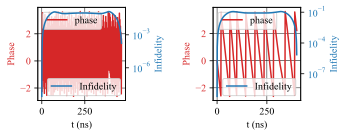

In [4]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:11<00:00, 39.75it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 474/474 [00:11<00:00, 41.72it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_95743/3740206178.py: 73

phase at the last time step: -1.54316875


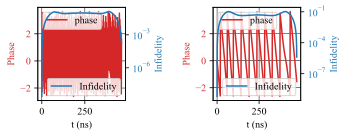

In [3]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.12.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

In [1]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.11.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

NameError: name 'qutip' is not defined

Processing: 100%|██████████| 463/463 [00:17<00:00, 26.59it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 341/341 [00:13<00:00, 26.09it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_98996/276614466.py: 73

phase at the last time step: -2.3152296874999996


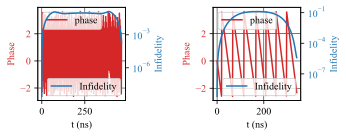

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.14.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:16<00:00, 28.52it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 294/294 [00:10<00:00, 28.74it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_99424/286679543.py: 73

phase at the last time step: -2.2106374999999994


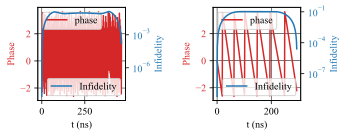

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.15.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:15<00:00, 28.97it/s]


phase at the last time step: 1.60195078125


Processing: 100%|██████████| 256/256 [00:08<00:00, 29.47it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_99703/1318242010.py: 73

phase at the last time step: 2.9534132812499996


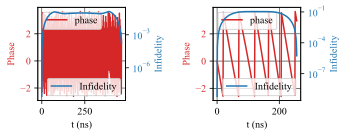

In [2]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.16.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing:   0%|          | 0/463 [00:00<?, ?it/s]

Processing: 100%|██████████| 463/463 [00:14<00:00, 31.82it/s]


phase at the last time step: 1.60215078125


Processing: 100%|██████████| 400/400 [00:11<00:00, 33.43it/s]
 /tmp/ipykernel_181035/2976401056.py: 73WARNING:matplotlib.font_manager:findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


phase at the last time step: 2.2353074218750004


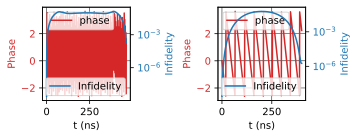

In [3]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.13_a0.003.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:13<00:00, 33.50it/s]


phase at the last time step: 1.60215078125


Processing: 100%|██████████| 294/294 [00:08<00:00, 35.64it/s]
 /tmp/ipykernel_181035/3163115851.py: 73WARNING:matplotlib.font_manager:findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


phase at the last time step: -2.20937265625


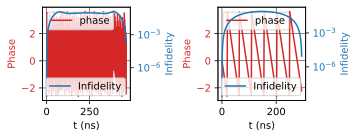

In [4]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.15_a0.003.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()

Processing: 100%|██████████| 463/463 [00:12<00:00, 37.55it/s]


phase at the last time step: 1.60215078125


Processing: 100%|██████████| 569/569 [00:17<00:00, 31.79it/s]
 /tmp/ipykernel_181035/1119946515.py: 73WARNING:matplotlib.font_manager:findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


phase at the last time step: -1.8836890625


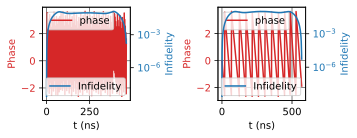

In [5]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level_sesolve.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_2.65.pkl',
            'pickles/mesolve_12_reference_states_two_level_sesolve_2.65_g0.11_a0.003.pkl',
            # 'pickles/mesolve_12_reference_states_two_level_sesolve_6.86.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([0],[results_combined[0:4]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        for result in results:
            assert len(results[0].times) == num_time_steps
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x[0])
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'wb') as file:
        #     pickle.dump((infidelity,phase), file)

        
        # with open(f'pickles/sesolve_reference_states_{i}{j}_(infidelity,phase)_small_g.pkl', 'rb') as file:
        #     infidelity,phase = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')
        
        print(f'phase at the last time step: {phase[-1]}')

fig.tight_layout()  # For a nicer layout
plt.show()